# Tarea — Unidad 4 · Preparación de datos para un modelo de riesgo de ictus (accidente cerebrovascular)

**FP13 · Inteligencia Artificial · UAG**
Subtemas 4.1 a 4.7

---

## Contexto

El **Stroke Prediction Dataset** contiene 5,110 registros de pacientes con 11 variables clínicas y
sociodemográficas. El desenlace `stroke` indica si el paciente presentó un evento cerebrovascular.

En la Práctica 7 trabajamos cada transformación por separado sobre datos de cardiopatía isquémica.
Aquí el encargo es distinto: **construir una matriz de modelado completa**, desde el archivo crudo
hasta la selección final de variables, y **justificar una decisión por columna**.

## Qué se evalúa

No se evalúa que el código corra: se evalúa que **cada decisión esté argumentada con evidencia
producida por usted**.

| Criterio | Peso |
|---|---|
| Corrección técnica del código (partes 1 a 9) | 40 % |
| Justificación escrita de cada decisión | 30 % |
| Tabla de decisiones por columna (Parte 10) | 15 % |
| Preguntas de reflexión | 15 % |

## Entrega

Este mismo notebook **ejecutado de arriba a abajo sin errores**, con todas las celdas de texto
completadas. Nombre el archivo `Tarea_U4_ApellidoNombre.ipynb`.

## Restricciones

- **No use `Pipeline` ni `ColumnTransformer`.** Todo se resuelve columna por columna, de forma
  explícita. Volveremos a encapsularlo en la Unidad 5.
- Fije la semilla al inicio y no la vuelva a tocar.
- Toda afirmación sobre los datos debe estar respaldada por una celda que la produzca.

---
## Parte 0 · Preparación

In [1]:
# [1] Entorno y semilla
# TODO: importe numpy, pandas, matplotlib.pyplot y scipy.stats.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
#       Fije SEED = 42 y configure la salida de pandas.
SEED = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
# [2] Ingesta del conjunto de datos
# TODO: cargue "healthcare-dataset-stroke-data.csv" en un DataFrame llamado df.
#       Puede usar kagglehub (dataset "fedesoriano/stroke-prediction-dataset") (https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)
#       o la copia local. Imprima la forma y las primeras filas.
# [2] Ingesta del conjunto de datos

df = pd.read_csv("healthcare-dataset-stroke-data.csv")

print("Forma del dataset:", df.shape)
df.head()

Forma del dataset: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


---
## Parte 1 · Reconocimiento (subtema 4.7)

Antes de modificar nada hay que saber qué se tiene. La clasificación de una variable en nominal,
binaria o numérica es una decisión **clínica**, no estadística: la toma usted, no `pandas`.

In [3]:
# [3] Inventario de columnas
# TODO: construya una tabla con, por columna: tipo de dato, numero de valores unicos,
#       numero de nulos y porcentaje de nulos.
inventario = pd.DataFrame({
    "tipo_dato": df.dtypes,
    "valores_unicos": df.nunique(),
    "nulos": df.isnull().sum(),
    "porcentaje_nulos": (df.isnull().sum() / len(df) * 100).round(2)
})

inventario

,tipo_dato,valores_unicos,nulos,porcentaje_nulos
id,int64,5110,0,0.00
gender,str,3,0,0.00
age,float64,104,0,0.00
hypertension,int64,2,0,0.00
heart_disease,int64,2,0,0.00
ever_married,str,2,0,0.00
work_type,str,5,0,0.00
Residence_type,str,2,0,0.00
avg_glucose_level,float64,3979,0,0.00
bmi,float64,418,201,3.93


In [4]:
# [4] Declaracion de roles
# TODO: defina las listas IDENT, NOMINALES, BINARIAS, INDICADOR, NUMERICAS y OBJETIVO.
#       Imprima las categorias de cada variable de texto con su frecuencia,
#       la prevalencia del objetivo y cuantos valores unicos toma la columna de folio.


IDENT     = "id"
NOMINALES = ["gender", "work_type", "smoking_status"]   # sin orden intrinseco
BINARIAS  = ["ever_married", "Residence_type"]          # dos categorias de texto
INDICADOR = ["hypertension", "heart_disease"]            # ya vienen como 0/1
NUMERICAS = ["age", "avg_glucose_level", "bmi"]
OBJETIVO  = "stroke"

print("Categorias de cada variable de texto:")
for c in NOMINALES + BINARIAS:
    print(f"  {c:<16} {dict(df[c].value_counts())}")

print(f"\nPrevalencia de ictus: {df[OBJETIVO].mean():.4f}")
print(f"Folios unicos: {df[IDENT].nunique()} de {len(df)} filas")



Categorias de cada variable de texto:
  gender           {'Female': np.int64(2994), 'Male': np.int64(2115), 'Other': np.int64(1)}
  work_type        {'Private': np.int64(2925), 'Self-employed': np.int64(819), 'children': np.int64(687), 'Govt_job': np.int64(657), 'Never_worked': np.int64(22)}
  smoking_status   {'never smoked': np.int64(1892), 'Unknown': np.int64(1544), 'formerly smoked': np.int64(885), 'smokes': np.int64(789)}
  ever_married     {'Yes': np.int64(3353), 'No': np.int64(1757)}
  Residence_type   {'Urban': np.int64(2596), 'Rural': np.int64(2514)}

Prevalencia de ictus: 0.0487
Folios unicos: 5110 de 5110 filas


**Responda antes de continuar.** Dos columnas categóricas contienen algo que no debería estar ahí:
una tiene una categoría con un solo paciente, otra tiene una categoría que no describe ninguna
condición clínica. Identifíquelas.

*Su respuesta:*
La columna gender contiene la categoría Other, que aparece en un solo paciente. Por otro lado, smoking_status contiene la categoría Unknown, que no describe una condición de tabaquismo conocida. 

---
## Parte 2 · Integridad de los registros: duplicados (subtema 4.7)

Eliminar duplicados es un paso obligatorio del protocolo. Pero *duplicado* no significa «filas
parecidas»: significa **el mismo paciente capturado dos veces**. Verifique en tres niveles **antes**
de borrar una sola fila.

In [5]:
# [5] Tres niveles de verificacion
# TODO: cuente (1) duplicados exactos sobre todas las columnas,
dup_exactos = df.duplicated().sum()
#       (2) duplicados ignorando la columna de folio,
columnas_sin_id = [c for c in df.columns if c != IDENT]
dup_sin_id = df.duplicated(subset=columnas_sin_id).sum()
#       (3) filas que repiten una llave clinica formada por las categoricas + age.
#       Reporte cuantas filas y cuantos perfiles distintos involucra el nivel 3.
llave_clinica = NOMINALES + BINARIAS + INDICADOR + ["age"]

mask_llave = df.duplicated(subset=llave_clinica, keep=False)
filas_llave = df.loc[mask_llave]

n_filas_llave = len(filas_llave)
n_perfiles_llave = filas_llave[llave_clinica].drop_duplicates().shape[0]

print("Nivel 1 - Duplicados exactos:", dup_exactos)
print("Nivel 2 - Duplicados sin folio:", dup_sin_id)
print("Nivel 3 - Filas con llave clinica repetida:", n_filas_llave)
print("Nivel 3 - Perfiles clinicos distintos repetidos:", n_perfiles_llave)

Nivel 1 - Duplicados exactos: 0
Nivel 2 - Duplicados sin folio: 0
Nivel 3 - Filas con llave clinica repetida: 3310
Nivel 3 - Perfiles clinicos distintos repetidos: 1019


In [7]:
# [6] La prueba decisiva
# TODO: repita el conteo del nivel 3 agregando bmi y avg_glucose_level a la llave.
#       Muestre dos registros con el mismo perfil clinico y mediciones distintas.
#       Decida: que filas elimina y que columnas elimina. Ejecute su decision.
llave_completa = llave_clinica + ["bmi", "avg_glucose_level"]
mask_completa = df.duplicated(subset=llave_completa, keep=False)

print("Filas con llave ampliada repetida:", mask_completa.sum())
print(
    "Perfiles distintos repetidos:",
    df.loc[mask_completa, llave_completa].drop_duplicates().shape[0]
)

# Mostrar dos registros con el mismo perfil clinico,
# pero con mediciones diferentes
ejemplo = (
    df.loc[mask_llave]
      .sort_values(llave_clinica)
      .groupby(llave_clinica, dropna=False)
      .filter(
          lambda x:
          x["bmi"].nunique(dropna=False) > 1
          or x["avg_glucose_level"].nunique(dropna=False) > 1
      )
)

ejemplo.head(2)

# Decision:
# No se eliminan filas porque no hay duplicados reales.
# Se elimina la columna id porque solo funciona como identificador.

df = df.drop(columns=[IDENT])

print("Forma del dataset despues de eliminar id:", df.shape)

Filas con llave ampliada repetida: 0
Perfiles distintos repetidos: 0
Forma del dataset despues de eliminar id: (5110, 11)


**Justifique su decisión.** ¿Cuántas filas eliminó y por qué? Si eliminó cero, dígalo
explícitamente y explique qué habría pasado con `drop_duplicates(subset=llave_clinica)`. Si eliminó
alguna columna, justifique por qué no aporta al modelo.

*Su respuesta:*
Se eliminaron 0 filas, porque no se encontraron duplicados reales. Aunque 3310 filas compartían la llave clínica inicial, al agregar bmi y avg_glucose_level no se encontraron registros repetidos. Si se hubiera usado drop_duplicates(subset=llave_clinica), se habrían eliminado pacientes diferentes que simplemente compartían algunas características clínicas. Se eliminó únicamente la columna id, ya que es un identificador único para cada paciente y no aporta información clínica útil para predecir el riesgo de ictus.

---
## Parte 3 · Valores faltantes: los declarados y los enmascarados

En la Práctica 7 el faltante se disfrazaba de número (colesterol = 0 mg/dL). Aquí hay faltantes de
dos tipos y uno de ellos se disfraza de **texto**.

In [8]:
# [7] Faltantes declarados y enmascarados
# TODO: (a) reporte los nulos declarados por columna.
print("Nulos declarados por columna:")
print(df.isnull().sum())

#       (b) localice la categoria de texto que en realidad significa "dato no disponible"
#           y cuente cuantos registros la tienen.
n_unknown = (df["smoking_status"] == "Unknown").sum()

print("\nRegistros con smoking_status = 'Unknown':", n_unknown)
print("Porcentaje:", round(n_unknown / len(df) * 100, 2), "%")
#       (c) compare la tasa del objetivo y la edad media entre los pacientes
#           con bmi presente y con bmi ausente.
comparacion_bmi = pd.DataFrame({
    "n_pacientes": [
        df["bmi"].notna().sum(),
        df["bmi"].isna().sum()
    ],
    "tasa_stroke": [
        df.loc[df["bmi"].notna(), OBJETIVO].mean(),
        df.loc[df["bmi"].isna(), OBJETIVO].mean()
    ],
    "edad_media": [
        df.loc[df["bmi"].notna(), "age"].mean(),
        df.loc[df["bmi"].isna(), "age"].mean()
    ]
}, index=["BMI presente", "BMI ausente"])

comparacion_bmi

Nulos declarados por columna:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Registros con smoking_status = 'Unknown': 1544
Porcentaje: 30.22 %


,n_pacientes,tasa_stroke,edad_media
BMI presente,4909,0.042575,42.865374
BMI ausente,201,0.199005,52.049154


**Interprete (c).** ¿El dato de `bmi` falta al azar? Si su respuesta es no, proponga un mecanismo
clínico que lo explique y diga qué consecuencia tiene para la imputación.

*Su respuesta:*
No, el bmi no parece faltar al azar. Los pacientes sin BMI tienen una edad promedio mayor y presentan más casos de ictus que los pacientes que sí tienen este dato. Esto podría pasar porque en algunos pacientes, especialmente los de mayor riesgo, no se registró el peso o la estatura. Por eso, no sería conveniente eliminar estos pacientes y se debe tener cuidado al rellenar los valores faltantes.

In [10]:
# [8] Mecanismo del faltante enmascarado
# TODO: calcule la proporcion de la categoria enmascarada segun work_type
#       y segun grupo de edad (use pd.cut con cortes 0-18-40-60-120).
#       Concluya si el patron es aleatorio.
es_unknown = df["smoking_status"] == "Unknown"

prop_work = df.assign(es_unknown=es_unknown).groupby("work_type")["es_unknown"].mean()

print("Proporcion de Unknown segun work_type:")
print(prop_work)

df["grupo_edad"] = pd.cut(
    df["age"],
    bins=[0, 18, 40, 60, 120],
    include_lowest=True
)

prop_edad = df.assign(es_unknown=es_unknown).groupby(
    "grupo_edad", observed=False
)["es_unknown"].mean()

print("\nProporcion de Unknown segun grupo de edad:")
print(prop_edad)

#Conclusión: El patrón no parece ser aleatorio. Unknown aparece principalmente en niños
#  y menores de 18 años. Esto tiene sentido porque en pacientes jóvenes puede no haberse 
# registrado información sobre tabaquismo. Por lo tanto, Unknown está relacionado con la 
# edad y el tipo de trabajo del paciente.

Proporcion de Unknown segun work_type:
work_type
Govt_job         0.185693
Never_worked     0.363636
Private          0.218803
Self-employed    0.190476
children         0.899563
Name: es_unknown, dtype: float64

Proporcion de Unknown segun grupo de edad:
grupo_edad
(-0.001, 18.0]    0.774017
(18.0, 40.0]      0.216867
(40.0, 60.0]      0.194622
(60.0, 120.0]     0.186350
Name: es_unknown, dtype: float64


BMI faltantes antes de imputar: 201

Comparacion:
                         n      media  desviacion  asimetria
Observados            4909  28.893237    7.854067   1.055340
Mediana global        5110  28.862035    7.699562   1.088187
Mediana condicionada  5110  28.870822    7.720488   1.070254


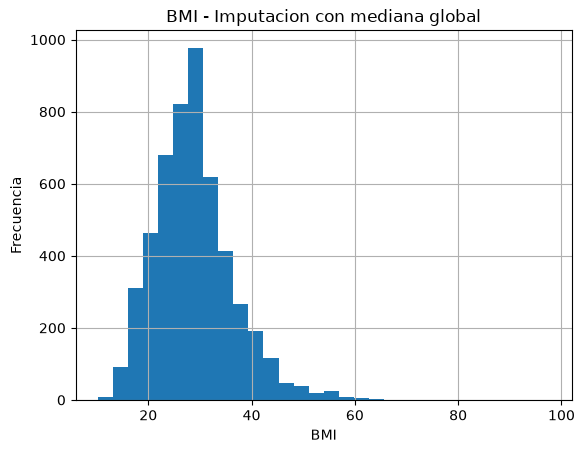

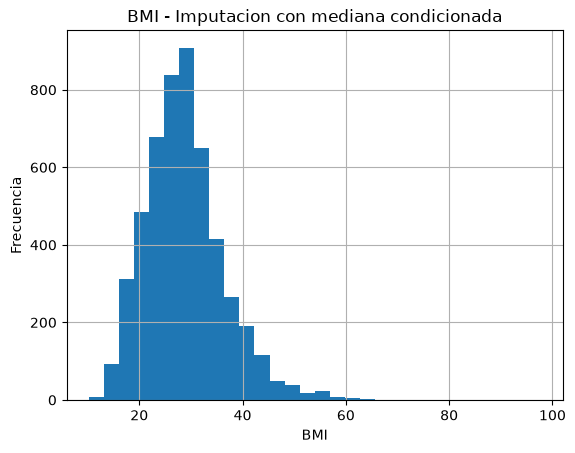

Nulos restantes en bmi: 0


In [12]:
# [9] Imputacion de bmi
# TODO: (a) cree la columna indicadora bmi_faltante ANTES de imputar.
df["bmi_faltante"] = df["bmi"].isna().astype(int)
print("BMI faltantes antes de imputar:", df["bmi"].isna().sum())
#       (b) construya dos versiones: mediana global y mediana condicionada
#           por grupo de edad y sexo.
# Version 1: mediana global
mediana_global = df["bmi"].median()
bmi_global = df["bmi"].fillna(mediana_global)

# Version 2: mediana segun grupo de edad y sexo
medianas_grupo = df.groupby(
    ["grupo_edad", "gender"],
    observed=False
)["bmi"].transform("median")

bmi_condicionada = df["bmi"].fillna(medianas_grupo)
#       (c) compare n, media, desviacion estandar y asimetria de las tres versiones
#           (observados, global, condicionada) e incluya un histograma de cada imputacion.
comparacion = pd.DataFrame({
    "n": [
        df["bmi"].count(),
        bmi_global.count(),
        bmi_condicionada.count()
    ],
    "media": [
        df["bmi"].mean(),
        bmi_global.mean(),
        bmi_condicionada.mean()
    ],
    "desviacion": [
        df["bmi"].std(),
        bmi_global.std(),
        bmi_condicionada.std()
    ],
    "asimetria": [
        df["bmi"].skew(),
        bmi_global.skew(),
        bmi_condicionada.skew()
    ]
}, index=["Observados", "Mediana global", "Mediana condicionada"])

print("\nComparacion:")
print(comparacion)


# Histogramas

plt.figure()
bmi_global.hist(bins=30)
plt.title("BMI - Imputacion con mediana global")
plt.xlabel("BMI")
plt.ylabel("Frecuencia")
plt.show()

plt.figure()
bmi_condicionada.hist(bins=30)
plt.title("BMI - Imputacion con mediana condicionada")
plt.xlabel("BMI")
plt.ylabel("Frecuencia")
plt.show()

#       (d) elija una, aplíquela a df y verifique que no quedan nulos.
df["bmi"] = bmi_condicionada

print("Nulos restantes en bmi:", df["bmi"].isna().sum())

**Justifique su elección.** ¿Qué le pasa a la desviación estándar al imputar y por qué? ¿Qué aporta
`bmi_faltante` que la imputación por sí sola pierde? ¿Y qué decidió hacer con la categoría
enmascarada de la celda [8] — imputarla o conservarla? Argumente.

*Su respuesta:*
Al imputar, la desviación estándar disminuyó de 7.85 a 7.72, porque los valores faltantes se reemplazaron por valores cercanos a la mediana y esto hace que haya menos variación. bmi_faltante permite identificar qué pacientes originalmente no tenían BMI, algo que se perdería al rellenarlos. Decidí conservar Unknown en smoking_status, porque vimos que aparece mucho más en niños y jóvenes, por lo que no parece estar ahí al azar y puede aportar información al modelo.

---
## Parte 4 · Valores atípicos (subtema 4.3)


Variable: age
Limite inferior: -29.00
Limite superior: 115.00
Numero de atipicos: 0
Maximo: 82.00

Variable: avg_glucose_level
Limite inferior: 21.98
Limite superior: 169.36
Numero de atipicos: 627
Maximo: 271.74

Variable: bmi
Limite inferior: 10.05
Limite superior: 46.45
Numero de atipicos: 123
Maximo: 97.60


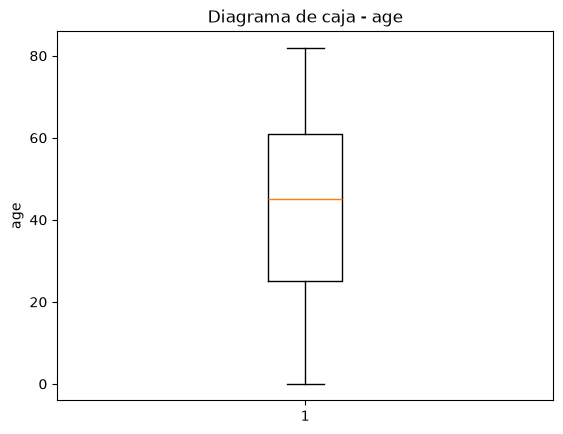

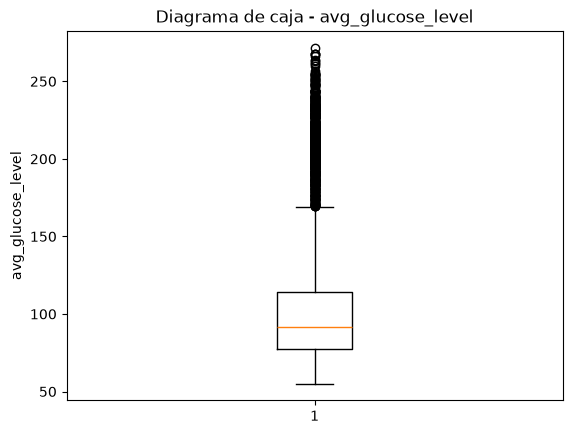

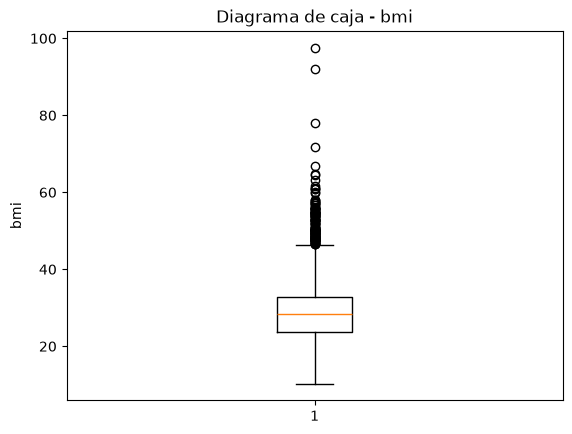

In [13]:
# [10] Deteccion por rango intercuartil
# TODO: escriba una funcion limites_iqr(x, k=1.5) que devuelva (Q1-k*IQR, Q3+k*IQR).
#       Aplíquela a las tres numericas: reporte limites, numero de atipicos y maximo.
#       Acompane con un diagrama de caja por variable.
def limites_iqr(x, k=1.5):
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - k * IQR
    limite_superior = Q3 + k * IQR
    
    return limite_inferior, limite_superior

for c in NUMERICAS:
    li, ls = limites_iqr(df[c])
    
    atipicos = ((df[c] < li) | (df[c] > ls)).sum()
    
    print(f"\nVariable: {c}")
    print(f"Limite inferior: {li:.2f}")
    print(f"Limite superior: {ls:.2f}")
    print(f"Numero de atipicos: {atipicos}")
    print(f"Maximo: {df[c].max():.2f}")

for c in NUMERICAS:
    plt.figure()
    plt.boxplot(df[c].dropna())
    plt.title(f"Diagrama de caja - {c}")
    plt.ylabel(c)
    plt.show()

In [14]:
# [11] Un atipico no es automaticamente un error
# TODO: para bmi, compare la tasa del objetivo dentro y fuera del limite superior.
#       Cuente los registros con bmi > 60 y reporte el maximo observado.
#       Calcule la asimetria antes y despues de una winsorizacion al percentil 99.
_, limite_sup_bmi = limites_iqr(df["bmi"])
tasa_dentro = df.loc[df["bmi"] <= limite_sup_bmi, OBJETIVO].mean()
tasa_fuera = df.loc[df["bmi"] > limite_sup_bmi, OBJETIVO].mean()

print("Tasa de stroke dentro del limite:", round(tasa_dentro, 4))
print("Tasa de stroke fuera del limite:", round(tasa_fuera, 4))

n_bmi_60 = (df["bmi"] > 60).sum()

print("\nRegistros con BMI > 60:", n_bmi_60)
print("BMI maximo observado:", df["bmi"].max())

asimetria_antes = df["bmi"].skew()
p99 = df["bmi"].quantile(0.99)
bmi_winsor = df["bmi"].clip(upper=p99)

asimetria_despues = bmi_winsor.skew()

print("\nPercentil 99:", round(p99, 2))
print("Asimetria antes:", round(asimetria_antes, 4))
print("Asimetria despues:", round(asimetria_despues, 4))

Tasa de stroke dentro del limite: 0.0493
Tasa de stroke fuera del limite: 0.0244

Registros con BMI > 60: 13
BMI maximo observado: 97.6

Percentil 99: 52.89
Asimetria antes: 1.0703
Asimetria despues: 0.6738


**Decida y justifique.** ¿Elimina, recorta o conserva los atípicos de `bmi`? Compare este caso con
los ceros de colesterol de la Práctica 7: ¿por qué allá la decisión fue inmediata y aquí no?
Anticipe qué implica su decisión para la Parte 8.

*Su respuesta:*
Decidí conservar los valores altos de bmi, porque aunque son poco comunes, no tenemos evidencia de que sean errores. En la Práctica 7 los valores de colesterol en 0 sí se podían corregir de inmediato porque un colesterol de 0 no es un valor válido. En cambio, un BMI muy alto sí puede existir. Para la Parte 8, esto significa que tendremos que considerar estos valores altos al momento de transformar o ajustar las variables numéricas.

---
## Parte 5 · Ingeniería de funciones (subtema 4.2)

Hasta aquí sólo ha limpiado. Ahora **agregue** información que el modelo no deduciría solo, usando
umbrales clínicos establecidos —no cortes arbitrarios.

In [15]:
# [12] Variables derivadas con criterio clinico
# TODO: construya al menos cuatro variables nuevas. Se sugieren:
#         - imc_cat        : clasificacion de la OMS (18.5 / 25 / 30 kg/m2)
#         - glucosa_cat    : umbrales de glucemia casual (140 / 200 mg/dL)
#         - n_comorbilidades : suma de hipertension y cardiopatia
#         - grupo_edad     : el que definio en la celda [8]
#       Para cada una, reporte el conteo y la tasa del objetivo por categoria.
#       Revise si la tasa es monotona en todas: una de ellas NO lo es.

# 1. Categoria de IMC
df["imc_cat"] = pd.cut(
    df["bmi"],
    bins=[-np.inf, 18.5, 25, 30, np.inf],
    labels=["Bajo peso", "Normal", "Sobrepeso", "Obesidad"],
    right=False
)

# 2. Categoria de glucosa
df["glucosa_cat"] = pd.cut(
    df["avg_glucose_level"],
    bins=[-np.inf, 140, 200, np.inf],
    labels=["<140", "140-199", ">=200"],
    right=False
)

# 3. Numero de comorbilidades
df["n_comorbilidades"] = df["hypertension"] + df["heart_disease"]

# 4. grupo_edad ya fue creado en la celda [8]


# Conteo y tasa de stroke por categoria
variables_derivadas = [
    "imc_cat",
    "glucosa_cat",
    "n_comorbilidades",
    "grupo_edad"
]

for c in variables_derivadas:
    resumen = df.groupby(c, observed=False)[OBJETIVO].agg(
        conteo="count",
        tasa_stroke="mean"
    )
    
    print(f"\n{c}:")
    print(resumen)


imc_cat:
           conteo  tasa_stroke
imc_cat                       
Bajo peso     337     0.002967
Normal       1264     0.028481
Sobrepeso    1558     0.069961
Obesidad     1951     0.052793

glucosa_cat:
             conteo  tasa_stroke
glucosa_cat                     
<140           4289     0.036372
140-199         387     0.095607
>=200           434     0.129032

n_comorbilidades:
                  conteo  tasa_stroke
n_comorbilidades                     
0                   4400     0.033864
1                    646     0.134675
2                     64     0.203125

grupo_edad:
                conteo  tasa_stroke
grupo_edad                         
(-0.001, 18.0]     916     0.002183
(18.0, 40.0]      1328     0.004518
(40.0, 60.0]      1562     0.040973
(60.0, 120.0]     1304     0.135736


**Justifique los umbrales.** Cite el criterio clínico de cada corte. ¿Alguna de sus derivadas es
monótona respecto de la tasa del objetivo? ¿Y cuál de ellas es una discretización de una variable
que **ya tiene** en la matriz? Anótelo: va a importar en la Parte 9.

*Su respuesta:* La única variable que no tiene un aumento continuo en la tasa de ictus es imc_cat, porque la tasa aumenta hasta sobrepeso y después disminuye en obesidad. Además, imc_cat, glucosa_cat y grupo_edad son formas de agrupar variables que ya tenemos (bmi, avg_glucose_level y age). Esto será importante después para evitar usar información repetida.

---
## Parte 6 · Codificación one-hot (subtema 4.4)

In [16]:
# [13] One-hot y el efecto del parametro drop
# TODO: con OneHotEncoder, compare el numero de columnas resultante con
#       drop=None, drop="first" y drop="if_binary".
#       Ajuste la version que elija, construya la matriz codificada y reporte su forma.
#       Identifique la columna con menor frecuencia y cuantos registros la activan.
from sklearn.preprocessing import OneHotEncoder

categoricas = NOMINALES + BINARIAS + [
    "imc_cat",
    "glucosa_cat",
    "grupo_edad"
]

# Comparar las tres opciones
for opcion in [None, "first", "if_binary"]:
    encoder_temp = OneHotEncoder(
        drop=opcion,
        sparse_output=False,
        handle_unknown="ignore"
    )
    
    X_temp = encoder_temp.fit_transform(df[categoricas])
    
    print(f"drop={opcion}: {X_temp.shape[1]} columnas")


# Elegimos drop="if_binary"
encoder = OneHotEncoder(
    drop="if_binary",
    sparse_output=False,
    handle_unknown="ignore"
)

X_codificada = encoder.fit_transform(df[categoricas])

nombres_columnas = encoder.get_feature_names_out(categoricas)

X_codificada = pd.DataFrame(
    X_codificada,
    columns=nombres_columnas,
    index=df.index
)

print("\nForma de la matriz codificada:", X_codificada.shape)


# Columna con menor frecuencia
frecuencias = X_codificada.sum()
col_menor = frecuencias.idxmin()

print("Columna con menor frecuencia:", col_menor)
print("Registros que la activan:", int(frecuencias[col_menor]))

drop=None: 27 columnas
drop=first: 19 columnas
drop=if_binary: 25 columnas

Forma de la matriz codificada: (5110, 25)
Columna con menor frecuencia: gender_Other
Registros que la activan: 1


In [17]:
# [14] Una categoria nunca vista
# TODO: ajuste un codificador sobre work_type con handle_unknown="ignore" y
#       transforme un DataFrame con una categoria inexistente (por ejemplo "Pensionado").
#       Describa que devuelve y que habria pasado con handle_unknown="error".
# Codificador para work_type
encoder_work = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoder_work.fit(df[["work_type"]])

# Crear un ejemplo con una categoria que no existe en los datos originales
nuevo = pd.DataFrame({
    "work_type": ["Pensionado"]
})

# Transformar
resultado = encoder_work.transform(nuevo)

print("Categorias conocidas:", encoder_work.categories_)
print("Resultado para 'Pensionado':", resultado)

Categorias conocidas: [array(['Govt_job', 'Never_worked', 'Private', 'Self-employed', 'children'],
      dtype=object)]
Resultado para 'Pensionado': [[0. 0. 0. 0. 0.]]


**Justifique su elección de `drop`.** ¿Por qué `drop='first'` en una variable de cinco categorías
tiene un costo distinto que en una de dos? ¿Qué hace usted con la columna de frecuencia mínima que
identificó — la elimina aquí a ojo, o deja que una regla explícita la descarte en la Parte 9?

*Su respuesta:*
Elegí drop="if_binary" porque en las variables de dos categorías basta con conservar una para representar ambas. En una variable de cinco categorías, usar drop="first" quitaría una categoría completa como referencia. La columna gender_Other, que solo aparece en 1 paciente, no la eliminé manualmente; la conservaré por ahora y dejaré que una regla definida en la Parte 9 decida si se elimina.

---
## Parte 7 · Transformación de la distribución (subtema 4.5)

In [18]:
# [15] Escalera de transformaciones
# TODO: para cada variable numerica, tabule la asimetria original y despues de
#       sqrt, log1p y Yeo-Johnson, e incluya el lambda estimado.
from sklearn.preprocessing import PowerTransformer

resultados = []

for c in NUMERICAS:
    x = df[c].astype(float)

    # Original
    asim_original = x.skew()

    # Raiz cuadrada
    x_sqrt = np.sqrt(x)
    asim_sqrt = pd.Series(x_sqrt).skew()

    # Log1p
    x_log = np.log1p(x)
    asim_log = pd.Series(x_log).skew()

    # Yeo-Johnson
    pt = PowerTransformer(method="yeo-johnson", standardize=False)
    x_yj = pt.fit_transform(x.to_numpy().reshape(-1, 1)).ravel()

    asim_yj = pd.Series(x_yj).skew()
    lambda_yj = pt.lambdas_[0]

    resultados.append({
        "variable": c,
        "original": asim_original,
        "sqrt": asim_sqrt,
        "log1p": asim_log,
        "yeo_johnson": asim_yj,
        "lambda": lambda_yj
    })

tabla_transformaciones = pd.DataFrame(resultados)

tabla_transformaciones.round(4)

,variable,original,sqrt,log1p,yeo_johnson,lambda
0,age,-0.1371,-0.7862,-1.6774,-0.2788,0.8602
1,avg_glucose_level,1.5723,1.2427,0.8895,0.0846,-1.0759
2,bmi,1.0703,0.4751,0.0212,-0.0007,-0.0249


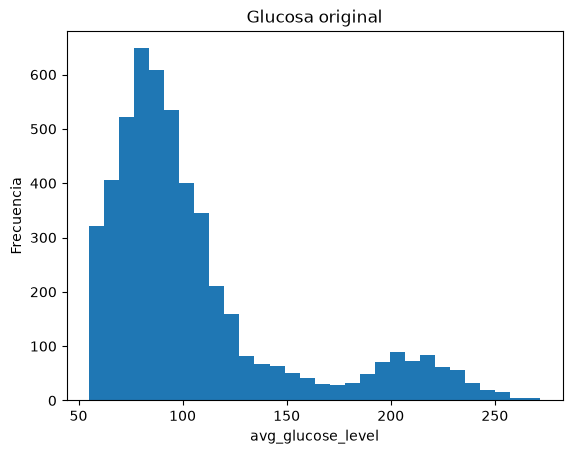

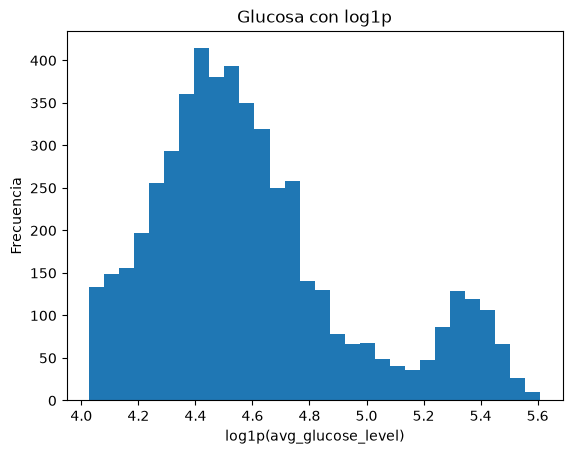

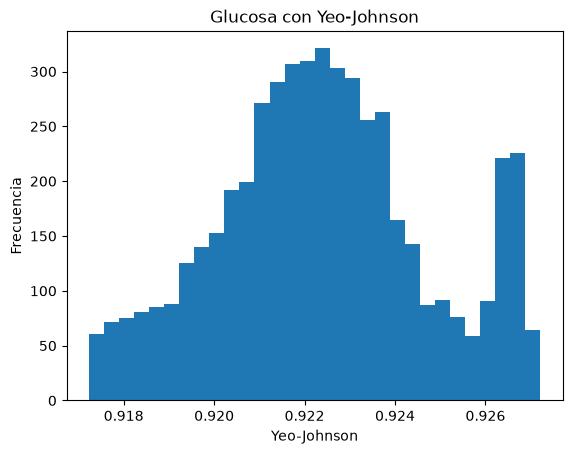

Porcentaje por categoria de glucosa:
glucosa_cat
<140       83.93
140-199     7.57
>=200       8.49
Name: proportion, dtype: float64


In [19]:
# [16] El caso dificil
# TODO: una de las tres variables mejora con el logaritmo pero NO queda simetrica.
#       Grafique su histograma original, logaritmico y Yeo-Johnson.
#       Reporte que porcentaje de pacientes cae en cada categoria clinica de esa variable.
# Variable a analizar
x = df["avg_glucose_level"].astype(float)

# Transformacion logaritmica
x_log = np.log1p(x)

# Transformacion Yeo-Johnson
pt_glucosa = PowerTransformer(
    method="yeo-johnson",
    standardize=False
)

x_yj = pt_glucosa.fit_transform(
    x.to_numpy().reshape(-1, 1)
).ravel()


# Histograma original
plt.figure()
plt.hist(x, bins=30)
plt.title("Glucosa original")
plt.xlabel("avg_glucose_level")
plt.ylabel("Frecuencia")
plt.show()


# Histograma logaritmico
plt.figure()
plt.hist(x_log, bins=30)
plt.title("Glucosa con log1p")
plt.xlabel("log1p(avg_glucose_level)")
plt.ylabel("Frecuencia")
plt.show()


# Histograma Yeo-Johnson
plt.figure()
plt.hist(x_yj, bins=30)
plt.title("Glucosa con Yeo-Johnson")
plt.xlabel("Yeo-Johnson")
plt.ylabel("Frecuencia")
plt.show()


# Porcentaje de pacientes en cada categoria clinica
porcentaje_glucosa = (
    df["glucosa_cat"]
    .value_counts(normalize=True, sort=False)
    .mul(100)
)

print("Porcentaje por categoria de glucosa:")
print(porcentaje_glucosa.round(2))

**Concluya variable por variable.** Para cada una de las tres numéricas: ¿transforma o no, y con
qué? Una de ellas **empeora** con el logaritmo: identifíquela y explique por qué. Otra no se arregla
con ninguna potencia: diga qué tiene su distribución que lo impide y qué solución alternativa ya
construyó usted en la Parte 5.

*Su respuesta:* Para age no aplicaría ninguna transformación, porque su asimetría original ya es baja (−0.1371) y el logaritmo la empeora hasta −1.6774. Para bmi usaría Yeo-Johnson, porque reduce su asimetría de 1.0703 a −0.0007. En avg_glucose_level, aunque Yeo-Johnson reduce la asimetría a 0.0846, la distribución tiene grupos o concentraciones de valores que una transformación de potencia no elimina por completo. Por eso, como alternativa ya construimos glucosa_cat, que divide la glucosa en <140, 140–199 y ≥200 y permite representar mejor esos grupos.

---
## Parte 8 · Escalamiento (subtema 4.6)

        escalador  minimo  maximo  amplitud_90  asimetria
0  StandardScaler -2.4056  8.9031       3.2326     1.0703
1    MinMaxScaler  0.0000  1.0000       0.2859     1.0703
2    RobustScaler -1.9780  7.6154       2.7423     1.0703


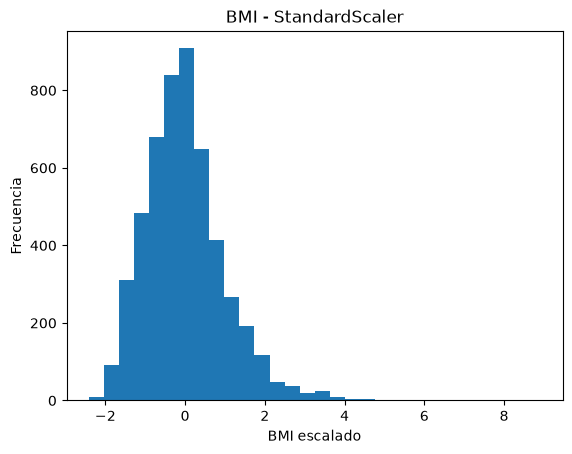

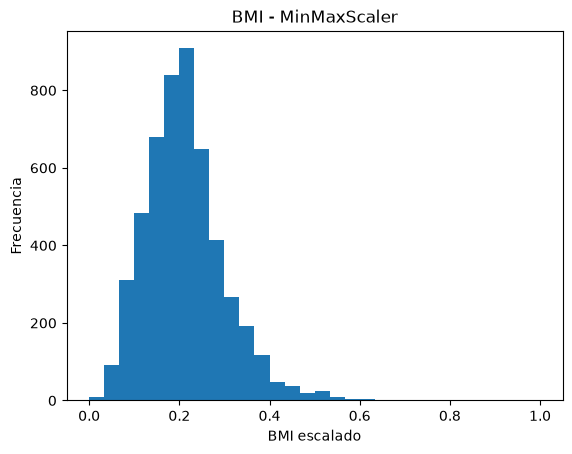

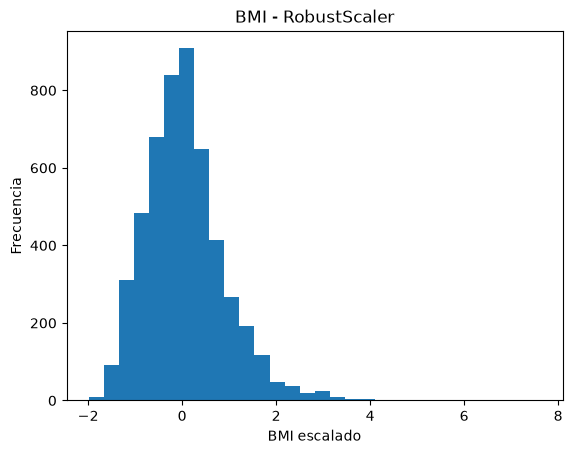

In [20]:
# [17] Comparacion de escaladores
# TODO: aplique StandardScaler, MinMaxScaler y RobustScaler a bmi.
#       Tabule minimo, maximo, amplitud del 90 % central (p95 - p5) y asimetria.
#       Grafique los tres histogramas resultantes.
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# BMI en formato de matriz
X_bmi = df[["bmi"]]

# Escaladores
escaladores = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

resultados_escalado = []
bmi_escalados = {}

for nombre, escalador in escaladores.items():
    
    # Aplicar escalador
    valores = escalador.fit_transform(X_bmi).ravel()
    bmi_escalados[nombre] = valores
    
    # Calcular medidas
    minimo = valores.min()
    maximo = valores.max()
    amplitud_90 = np.percentile(valores, 95) - np.percentile(valores, 5)
    asimetria = pd.Series(valores).skew()
    
    resultados_escalado.append({
        "escalador": nombre,
        "minimo": minimo,
        "maximo": maximo,
        "amplitud_90": amplitud_90,
        "asimetria": asimetria
    })

# Tabla comparativa
tabla_escaladores = pd.DataFrame(resultados_escalado)

print(tabla_escaladores.round(4))


# Histogramas
for nombre, valores in bmi_escalados.items():
    plt.figure()
    plt.hist(valores, bins=30)
    plt.title(f"BMI - {nombre}")
    plt.xlabel("BMI escalado")
    plt.ylabel("Frecuencia")
    plt.show()

**Explique dos cosas.** Primero: por qué la columna de asimetría es idéntica en los tres
escaladores. Segundo: cuál elige y cómo se conecta esa elección con la decisión que tomó sobre los
atípicos en la Parte 4. Diga además qué columnas **no** va a escalar y por qué.

*Su respuesta:* La asimetría es igual (1.0703) con los tres escaladores porque estos solo cambian la escala de los datos, pero no la forma de su distribución. Elegiría RobustScaler para bmi, porque es menos sensible a valores extremos y en la Parte 4 decidimos conservar los BMI altos en lugar de eliminarlos. No escalaría las variables categóricas, binarias, indicadoras ni las variables creadas por categorías, porque no son medidas numéricas continuas. Tampoco escalaría stroke, ya que es la variable que queremos predecir.

---
## Parte 9 · Selección de funciones (subtema 4.1)

Llegó con más columnas de las que empezó. Decida cuáles se quedan aplicando **tres criterios
independientes**: varianza, relevancia y redundancia. Ninguno basta por sí solo.

In [21]:
# [18] Ensamblado de la matriz de modelado
# TODO: concatene las numericas, los indicadores, sus variables derivadas numericas
#       y la matriz one-hot en un DataFrame X. Separe el objetivo en y.
#       Reporte la forma y el listado de columnas.
# Variables numericas
numericas_modelo = df[NUMERICAS].copy()

# Indicadores
indicadores_modelo = df[INDICADOR].copy()

# Variables derivadas numericas
derivadas_numericas = df[
    ["bmi_faltante", "n_comorbilidades"]
].copy()

# Unir todo con la matriz one-hot creada anteriormente
X = pd.concat(
    [
        numericas_modelo,
        indicadores_modelo,
        derivadas_numericas,
        X_codificada
    ],
    axis=1
)

# Variable objetivo
y = df[OBJETIVO].copy()

# Resultados
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

print("\nColumnas de X:")
print(X.columns.tolist())

Forma de X: (5110, 32)
Forma de y: (5110,)

Columnas de X:
['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'bmi_faltante', 'n_comorbilidades', 'gender_Female', 'gender_Male', 'gender_Other', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'ever_married_Yes', 'Residence_type_Urban', 'imc_cat_Bajo peso', 'imc_cat_Normal', 'imc_cat_Obesidad', 'imc_cat_Sobrepeso', 'glucosa_cat_140-199', 'glucosa_cat_<140', 'glucosa_cat_>=200', 'grupo_edad_(-0.001, 18.0]', 'grupo_edad_(18.0, 40.0]', 'grupo_edad_(40.0, 60.0]', 'grupo_edad_(60.0, 120.0]']


In [22]:
# [19] Criterio 1 - varianza casi nula
# TODO: aplique VarianceThreshold(0.01) y liste las columnas descartadas.
#       Muestre las cinco varianzas mas bajas.

from sklearn.feature_selection import VarianceThreshold

# Calcular la varianza de cada columna
varianzas = X.var()

# Mostrar las cinco varianzas mas bajas
print("Cinco varianzas mas bajas:")
print(varianzas.sort_values().head(5))

# Aplicar VarianceThreshold
selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X)

# Identificar columnas descartadas
columnas_descartadas = X.columns[~selector_var.get_support()].tolist()

print("\nColumnas descartadas:")
print(columnas_descartadas)

Cinco varianzas mas bajas:
gender_Other              0.000196
work_type_Never_worked    0.004288
bmi_faltante              0.037795
heart_disease             0.051104
imc_cat_Bajo peso         0.061612
dtype: float64

Columnas descartadas:
['gender_Other', 'work_type_Never_worked']


In [23]:
# [20] Criterio 2 - relevancia frente al objetivo
# TODO: calcule mutual_info_classif y la correlacion de Pearson de cada columna con y.
#       Presente ambas en una sola tabla ordenada por informacion mutua.

from sklearn.feature_selection import mutual_info_classif

# Informacion mutua
mi = mutual_info_classif(
    X,
    y,
    random_state=SEED
)

# Correlacion de Pearson
pearson = X.corrwith(y)

# Crear tabla
tabla_relevancia = pd.DataFrame({
    "informacion_mutua": mi,
    "correlacion_pearson": pearson.values
}, index=X.columns)

# Ordenar de mayor a menor informacion mutua
tabla_relevancia = tabla_relevancia.sort_values(
    by="informacion_mutua",
    ascending=False
)

print(tabla_relevancia)

                                informacion_mutua  correlacion_pearson
age                                      0.036921             0.245257
grupo_edad_(60.0, 120.0]                 0.027510             0.236550
n_comorbilidades                         0.017562             0.174616
grupo_edad_(18.0, 40.0]                  0.009889            -0.121679
glucosa_cat_>=200                        0.008302             0.113633
bmi                                      0.007925             0.040488
work_type_children                       0.007708            -0.083869
ever_married_Yes                         0.007676             0.108340
avg_glucose_level                        0.005313             0.131945
grupo_edad_(-0.001, 18.0]                0.005225            -0.101032
glucosa_cat_<140                         0.004199            -0.131171
grupo_edad_(40.0, 60.0]                  0.003891            -0.023899
heart_disease                            0.003479             0.134914
work_t

In [24]:
# [21] Criterio 3 - redundancia entre predictores
# TODO: (a) calcule la correlacion de age con al menos tres columnas one-hot,
#       (b) la de cada variable continua con su version discretizada de la Parte 5,
#       (c) verifique si alguna de sus variables derivadas es una combinacion lineal
#           EXACTA de otras columnas de la matriz. Si la hay, es la misma trampa
#           de la Practica 7 y debe resolverse igual.
# (a) Correlacion de age con columnas one-hot
columnas_age = [
    "grupo_edad_(-0.001, 18.0]",
    "grupo_edad_(18.0, 40.0]",
    "grupo_edad_(60.0, 120.0]"
]

print("(a) Correlacion de age con columnas one-hot:")
for c in columnas_age:
    print(c, ":", round(X["age"].corr(X[c]), 4))


# (b) Correlacion de variables continuas con sus versiones discretizadas
print("\n(b) Variables continuas vs. versiones discretizadas:")

pares = {
    "age": [c for c in X.columns if c.startswith("grupo_edad_")],
    "bmi": [c for c in X.columns if c.startswith("imc_cat_")],
    "avg_glucose_level": [c for c in X.columns if c.startswith("glucosa_cat_")]
}

for variable, columnas in pares.items():
    print(f"\n{variable}:")
    for c in columnas:
        print(c, ":", round(X[variable].corr(X[c]), 4))


# (c) Comprobar combinacion lineal exacta
combinacion = X["hypertension"] + X["heart_disease"]

es_exacta = np.allclose(
    X["n_comorbilidades"],
    combinacion
)

print("\n(c) ¿n_comorbilidades es una combinacion lineal exacta?")
print(es_exacta)

print(
    "Diferencia maxima:",
    np.abs(X["n_comorbilidades"] - combinacion).max()
)

(a) Correlacion de age con columnas one-hot:
grupo_edad_(-0.001, 18.0] : -0.7037
grupo_edad_(18.0, 40.0] : -0.3432
grupo_edad_(60.0, 120.0] : 0.7321

(b) Variables continuas vs. versiones discretizadas:

age:
grupo_edad_(-0.001, 18.0] : -0.7037
grupo_edad_(18.0, 40.0] : -0.3432
grupo_edad_(40.0, 60.0] : 0.2198
grupo_edad_(60.0, 120.0] : 0.7321

bmi:
imc_cat_Bajo peso : -0.4214
imc_cat_Normal : -0.5015
imc_cat_Obesidad : 0.7634
imc_cat_Sobrepeso : -0.1085

avg_glucose_level:
glucosa_cat_140-199 : 0.4032
glucosa_cat_<140 : -0.8812
glucosa_cat_>=200 : 0.7781

(c) ¿n_comorbilidades es una combinacion lineal exacta?
True
Diferencia maxima: 0


**Interprete los tres criterios.** Hay una variable cuya posición en el ranking cambia mucho según
se mida con información mutua o con correlación de Pearson: identifíquela y explique qué mide cada
criterio. Hay al menos dos columnas que son, en buena medida, la edad disfrazada: nómbrelas con su
coeficiente. Y decida el destino de **cada una** de las variables que usted construyó en la Parte 5:
diga cuáles conserva y con qué evidencia. No todas deberían sobrevivir.

*Su respuesta:* bmi_faltante cambia bastante: tiene información mutua de 0.0017, pero correlación de 0.1412. La primera busca si existe alguna relación, mientras que Pearson mide qué tanto cambian juntas las variables. Las columnas que representan mucho la edad son grupo_edad_(-0.001, 18.0] (−0.7037) y grupo_edad_(60.0, 120.0] (0.7321). Conservaría grupo_edad y glucosa_cat porque mostraron relación con el ictus. Eliminaría imc_cat porque ya tenemos bmi, y n_comorbilidades porque es exactamente la suma de hypertension y heart_disease.

In [25]:
# [22] Matriz final
# TODO: elimine las columnas que sus tres criterios descartaron, escale las continuas
#       con el escalador que eligio en la Parte 8, y reporte la forma final
#       junto con las primeras filas.

from sklearn.preprocessing import RobustScaler

# Crear copia de X
X_final = X.copy()

# Columnas que decidimos eliminar
columnas_eliminar = [
    "gender_Other",
    "work_type_Never_worked",
    "n_comorbilidades",
    "imc_cat_Bajo peso",
    "imc_cat_Normal",
    "imc_cat_Obesidad",
    "imc_cat_Sobrepeso"
]

X_final = X_final.drop(columns=columnas_eliminar)

# Escalar variables continuas
continuas = ["age", "avg_glucose_level", "bmi"]

escalador_final = RobustScaler()
X_final[continuas] = escalador_final.fit_transform(
    X_final[continuas]
)

# Mostrar resultado
print("Forma final de X:", X_final.shape)
print("\nPrimeras filas:")
X_final.head()

Forma final de X: (5110, 25)

Primeras filas:


,age,avg_glucose_level,bmi,hypertension,heart_disease,bmi_faltante,gender_Female,gender_Male,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,ever_married_Yes,Residence_type_Urban,glucosa_cat_140-199,glucosa_cat_<140,glucosa_cat_>=200,"grupo_edad_(-0.001, 18.0]","grupo_edad_(18.0, 40.0]","grupo_edad_(40.0, 60.0]","grupo_edad_(60.0, 120.0]"
0,0.611111,3.712987,0.912088,0,1,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.444444,2.994300,0.087912,0,0,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.972222,0.380920,0.461538,0,1,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.111111,2.153481,0.670330,0,0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.944444,2.231917,-0.472527,1,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


---
## Parte 10 · Tabla de decisiones

Complete una fila por cada columna del conjunto original. Ésta es la entrega que se califica con más
peso: es el resumen ejecutable de todo su criterio.

| Columna | Faltantes | Atípicos | Codificación | Transformación | Escalamiento | ¿Se conserva? |
|---|---|---|---|---|---|---|
| `id` | 0 | No aplica | No  | Ninguna | No | No, es solo identificador |
| `gender` | 0 | No aplica | one-hot | Ninguna | No | Sí, excepto gender_Other por baja varianza |
| `age` | 0 | 0 | No | Ninguna | RobustScaler | Si |
| `hypertension` | 0 | No aplica | Ya es 0/1 | Ninguna | No | si |
| `heart_disease` | 0 | No aplica | Ya es 0/1 | Ninguna | no | si |
| `ever_married` | 0 | No aplica | Ya es 0/1 | Ninguna | no | si |
| `work_type` | 0 | No aplica | Ya es 0/1 | Ninguna | no | Sí, excepto Never_worked por baja varianza |
| `Residence_type` | 0 | No aplica | One-hot | Ninguna | no | si |
| `avg_glucose_level` | 0 | 627 | No | Ninguna | RobustScaler | si |
| `bmi` | 201 (3.93%) | 123 | no | Imputación por mediana según edad y género | RobustScaler | si |
| `smoking_status` | 0 (Unknown: 30.22%) | no aplica |one-hot | Se conserva Unknown | no | si |

---

## Preguntas de reflexión

Responda en dos o tres párrafos cada una, apoyándose en las cifras que produjo.

1. ¿Bajo qué condición dos filas con el mismo perfil clínico **sí** serían el mismo paciente? ¿Qué
   columna tendría que existir en el conjunto para poder afirmarlo?
   Dos filas con características clínicas iguales no necesariamente pertenecen al mismo paciente. En nuestro caso encontramos 3310 filas que compartían algunas características, pero al agregar bmi y avg_glucose_level encontramos 0 registros completamente repetidos.

   Para poder asegurar que dos registros pertenecen a la misma persona necesitaríamos un identificador único del paciente que pudiera repetirse en diferentes consultas. La columna id de este conjunto no permite hacerlo porque los 5110 registros tienen un id diferente.
2. Encontró una diferencia grande en la tasa del objetivo entre pacientes con y sin `bmi`
   registrado. ¿Qué mecanismo clínico podría explicarla y por qué la imputación sola es
   insuficiente?
   Los pacientes con BMI registrado tuvieron una tasa de ictus de 4.26 %, mientras que en los pacientes sin BMI fue de 19.90 %. Además, los pacientes sin BMI tenían una edad promedio mayor: 52.05 años frente a 42.87 años.

   Esto podría ocurrir porque el BMI se registra de manera diferente según la condición o situación del paciente. Por eso, solamente rellenar el dato faltante no es suficiente, ya que perderíamos la información de que originalmente faltaba. Por esta razón también creamos y conservamos bmi_faltante.
3. La categoría enmascarada de `smoking_status` y los ceros de colesterol de la Práctica 7 son
   ambos faltantes disfrazados. Si les dio tratamientos distintos, justifique la diferencia.
   Aunque ambos representan información desconocida, no los tratamos igual. En smoking_status, Unknown apareció en 1544 pacientes (30.22 %) y encontramos un patrón claro: estaba presente en aproximadamente 89.96 % de los niños. Por eso decidimos conservarlo como una categoría.

   En cambio, en la Práctica 7 el colesterol en cero representaba un valor que no tenía sentido como medición clínica. Por eso debía tratarse como un dato faltante y no como una categoría con información propia.
4. Una de sus variables no se corrige con ninguna transformación de potencia. ¿Por qué? ¿Qué
   propiedad de su distribución lo impide?
   La variable fue avg_glucose_level. Su asimetría original fue 1.5723; con logaritmo bajó a 0.8895 y con Yeo-Johnson a 0.0846. Aunque mejora, la transformación no elimina los distintos grupos que existen dentro de los valores de glucosa.

   Por eso creamos glucosa_cat, separando a los pacientes en <140, 140-199 y ≥200. En estos grupos quedaron 83.93 %, 7.57 % y 8.49 % de los pacientes, respectivamente.
5. Suponga que su modelo se despliega en un hospital donde el 40 % de los expedientes llega sin
   `bmi`. ¿Qué decisión de esta tarea cambiaría y cuál mantendría?
   Si el 40 % de los pacientes llegara sin BMI, revisaría nuevamente la forma de rellenar el BMI, porque en nuestros datos originales solamente faltaba en 3.93 %. Con una cantidad tan grande de datos faltantes, la imputación tendría mucho más efecto sobre los resultados.

   Lo que sí mantendría sería bmi_faltante, porque permitiría al modelo saber cuáles pacientes tenían un BMI real y cuáles recibieron uno rellenado. Con 40 % de datos faltantes, esa información sería incluso más importante.
6. ¿Qué criterio distingue una discretización útil de una redundante? Apóyese en el destino que le
   dio a sus propias variables derivadas.
   Una discretización es útil cuando ayuda a representar información importante de una variable sin limitarse a repetir lo que ya tenemos. Por ejemplo, conservamos glucosa_cat porque los grupos mostraron diferencias claras en la tasa de ictus: 3.64 %, 9.56 % y 12.90 %.

   En cambio, eliminamos imc_cat porque ya conservamos bmi y sus categorías no mostraron un aumento claro en la tasa de ictus. También eliminamos n_comorbilidades, porque comprobamos que era exactamente la suma de hypertension y heart_disease, así que no agregaba información nueva.

*Sus respuestas:*